In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from rough_volatility.config import load_config
from rough_volatility.experiments import load_artifact_manifest, run_all
from rough_volatility.plotting import CHART_CONTRACTS, generate_static_figures

project_root = Path.cwd().resolve()
config_path = project_root / Path('configs/full.yaml')
config = load_config(config_path)
np.random.seed(config.seed)
try:
    manifest = load_artifact_manifest(config, project_root)
except (FileNotFoundError, ValueError):
    manifest = run_all(config, project_root, force=False)

figure_dir = project_root / config.output.artifacts_dir / 'figures'
if not all((figure_dir / f'{name}.png').exists() for name in CHART_CONTRACTS):
    generate_static_figures(config, project_root, manifest)

validation = json.loads(manifest['validation_checks'].read_text(encoding='utf-8'))
skew_power = pd.read_csv(manifest['skew_power_law'])
hurst_summary = pd.read_csv(manifest['hurst_summary'])
hawkes_summary = pd.read_csv(manifest['hawkes_summary'])
print(f"profile={config.profile} seed={config.seed} fingerprint={config.fingerprint()}")
print(f"validation_all_passed={validation['checks']['all_passed']}")


profile=full seed=1210 fingerprint=6cb7f371657e
validation_all_passed=True


<a id="executive-summary"></a>

## 1. Technical summary

This notebook reproduces the complete synthetic rough-volatility lab. The central result is that clean rough-path scaling, normalized rough Bergomi variance, short-maturity skew, and clustered Hawkes activity can all be demonstrated together—while the noise experiment shows why an estimated $H<1/2$ is not identifying evidence by itself.

In [2]:
display(skew_power[['h', 'beta', 'theoretical_beta', 'h_implied', 'r_squared', 'ok']])

,h,beta,theoretical_beta,h_implied,r_squared,ok
0,0.05,-0.450419,-0.45,0.049581,0.999633,True
1,0.10,-0.405701,-0.40,0.094299,0.999608,True
2,0.20,-0.311825,-0.30,0.188175,0.999875,True
3,0.50,-0.013170,0.00,0.486830,0.128661,True


<a id="conceptual-map"></a>

## 2. From rough paths to option skew and order flow

The evidence chain is **rough paths → rough log-volatility → stochastic-volatility prices → implied-volatility skew**, with Hawkes order flow as a separate pedagogical route to a rough-looking proxy. Arrows organize experiments; they are not causal-identification claims.

<a id="mathematical-definitions"></a>

## 3. Definitions and scaling laws

The core definitions are

$$\operatorname{Cov}(B_t^H,B_s^H)=\frac12\left(t^{2H}+s^{2H}-|t-s|^{2H}\right),$$

$$S_q(\Delta)=\mathbb E|X_{t+\Delta}-X_t|^q\propto\Delta^{qH},$$

$$V_t=\xi_0(t)\exp\left(\eta\widetilde W_t^H-\frac12\eta^2t^{2H}\right),$$

and $|\mathrm{ATM\ skew}(T)|\propto T^{H-1/2}$.

<a id="configuration"></a>

## 4. Scope, synthetic data, and configuration

All rows below are synthetic and generated locally from the resolved YAML profile. Monte Carlo path counts, maturity grids, Hurst replications, and event-process horizons are explicit so comparisons can be audited.

In [3]:
display(pd.json_normalize(config.to_dict(), sep='.').T.rename(columns={0: 'resolved value'}))

,resolved value
profile,full
seed,1210
fbm.h_values,"(0.1, 0.5, 0.8)"
fbm.n_steps,8192
fbm.n_paths,300
...,...
noise.aggregate_window,4
noise.preaverage_window,4
output.artifacts_dir,artifacts
output.reports_dir,reports


<a id="fbm-path-comparison"></a>

## 5. Lower H changes local texture, not simply volatility

At a matched horizon scale, lower $H$ changes local regularity rather than merely increasing unconditional amplitude.

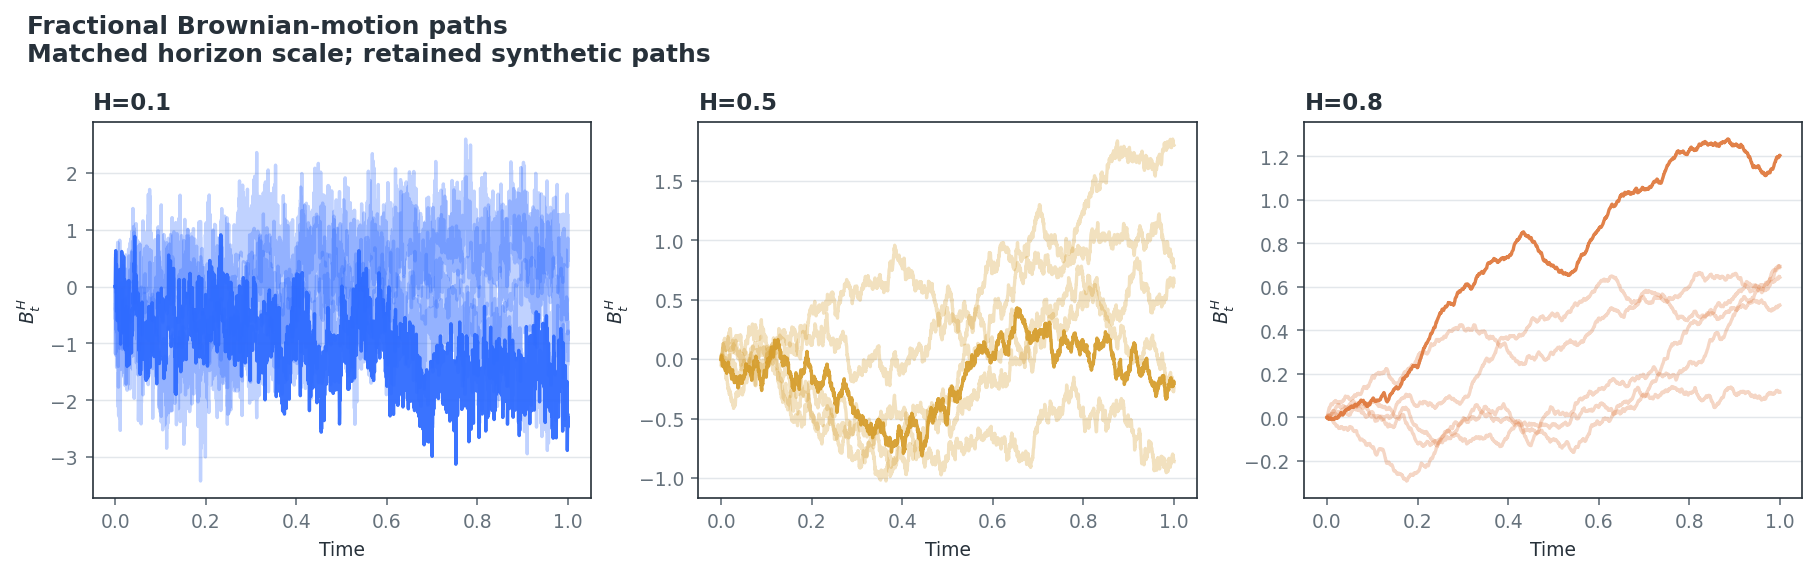

In [4]:
for figure_name in ['fbm_paths']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="local-zoom"></a>

## 6. Roughness remains visible under a local zoom

A local window isolates texture from the broad range of a path. The rough path continues to oscillate more sharply after zooming.

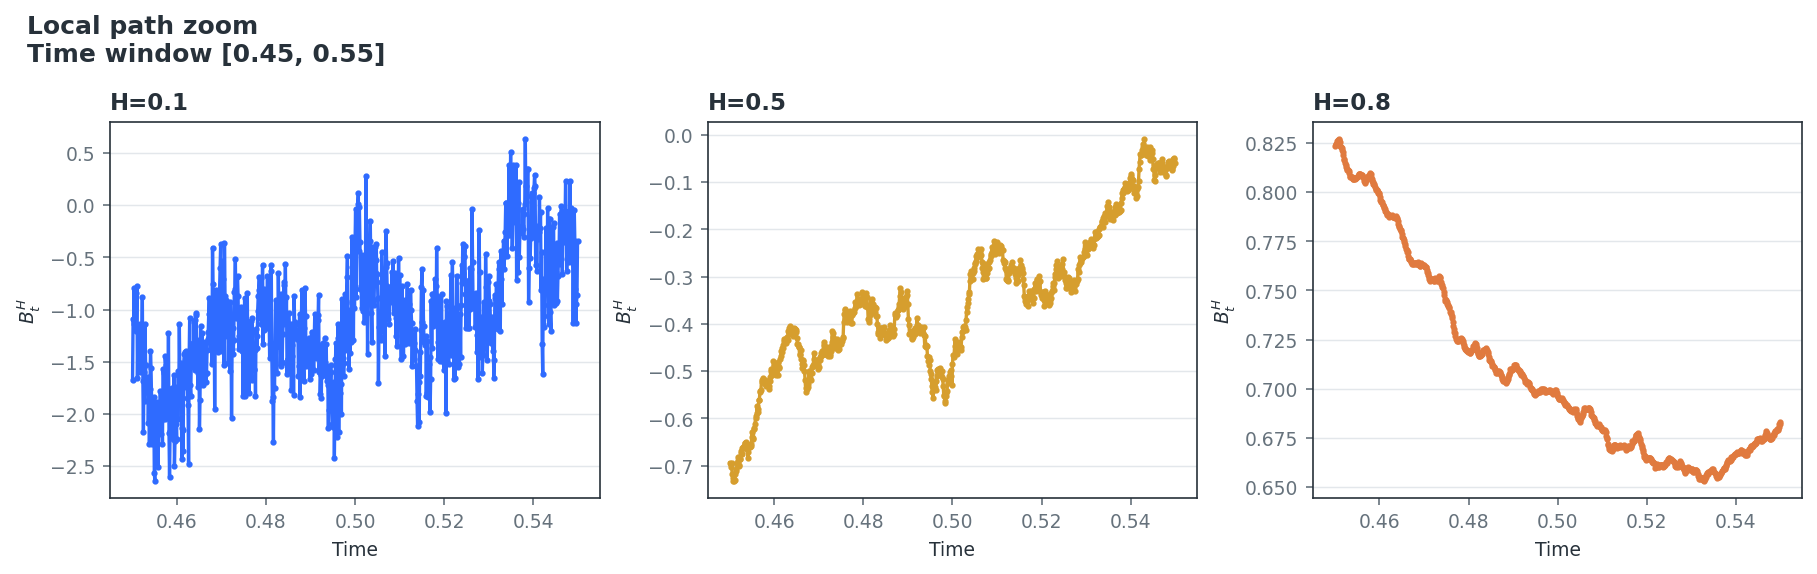

In [5]:
for figure_name in ['fbm_zoom']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="fgn-increments"></a>

## 7. Rough increments alternate sharply

Fractional Gaussian-noise increments make the fine-scale alternation visible directly.

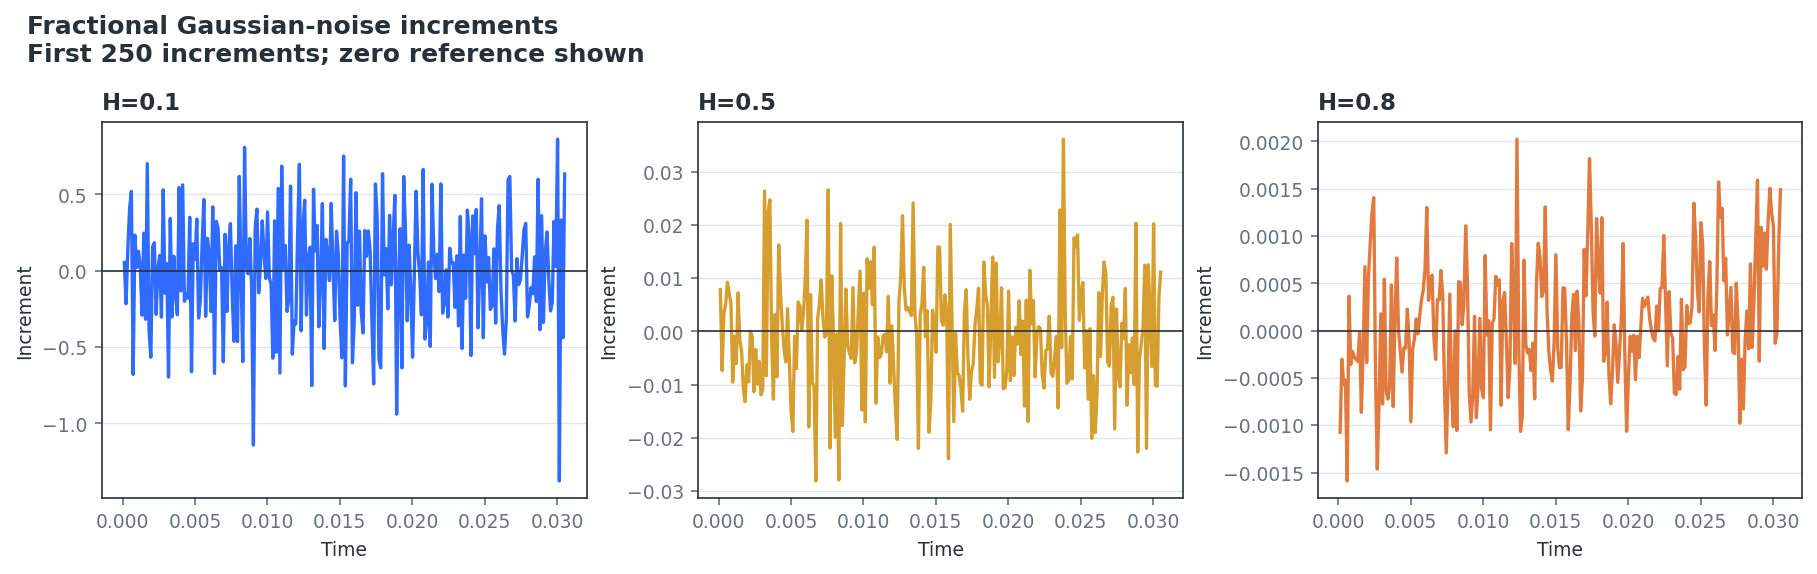

In [6]:
for figure_name in ['fgn_increments']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="increment-acf"></a>

## 8. Short-lag increments become anti-persistent below H=1/2

For $H<1/2$, short-lag increments are anti-persistent even when process levels can look persistent.

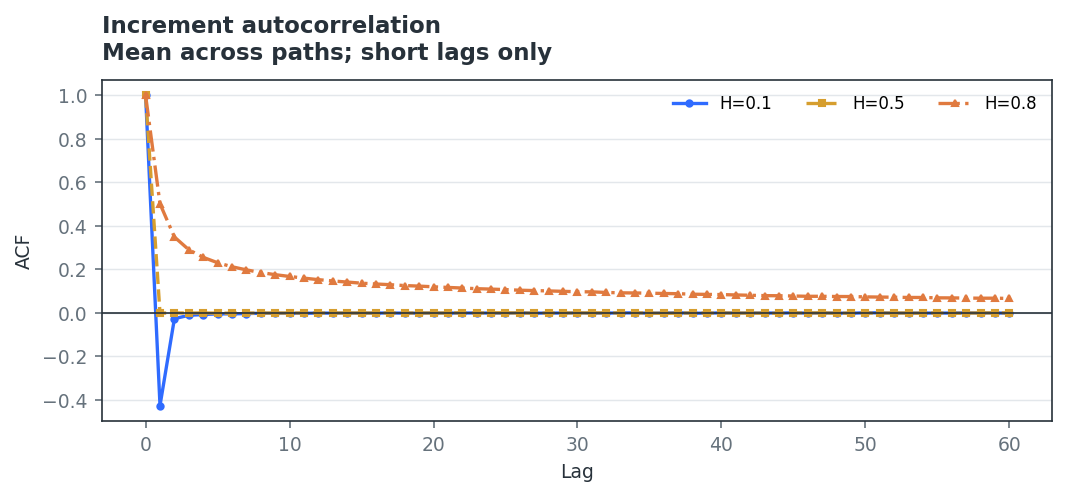

In [7]:
for figure_name in ['increment_acf']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="structure-functions"></a>

## 9. Structure-function slopes recover the H ordering

The second-order log–log slope estimates $2H$. Only bounded log-spaced lags are used to avoid the noisiest long-lag tail.

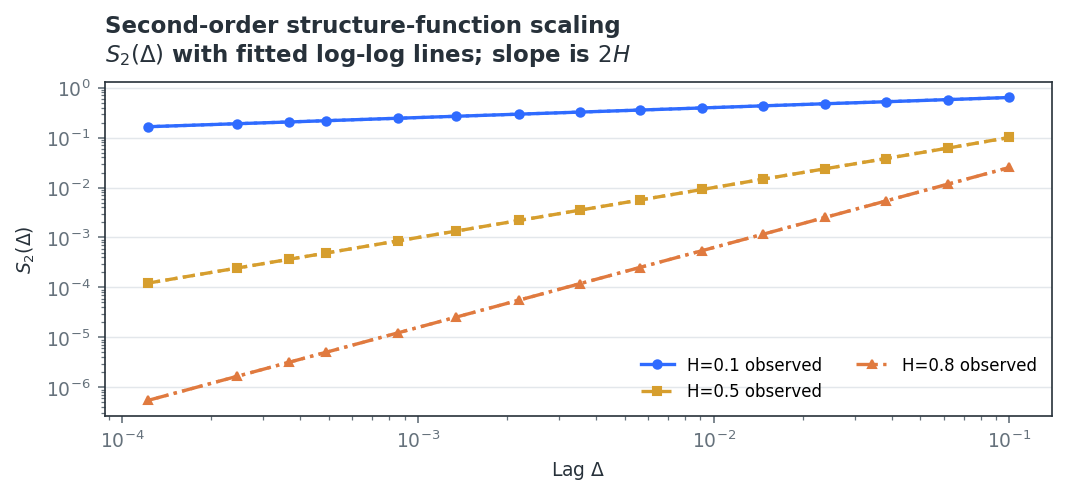

In [8]:
for figure_name in ['structure_scaling']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="hurst-recovery"></a>

## 10. Finite samples disperse H estimates

Estimator distributions remain dispersed in finite samples, including on perfectly clean synthetic fBM.

In [9]:
display(hurst_summary[['true_h', 'sample_size', 'estimator', 'mean_h_hat', 'bias', 'rmse', 'coverage']])

,true_h,sample_size,estimator,mean_h_hat,bias,rmse,coverage
0,0.1,512,aggregated_variance,0.096541,-0.003459,0.046410,0.900
1,0.1,512,madogram,0.097330,-0.002670,0.021372,0.466
2,0.1,512,variogram,0.096628,-0.003372,0.020956,0.430
3,0.1,2048,aggregated_variance,0.099010,-0.000990,0.025221,0.856
4,0.1,2048,madogram,0.099797,-0.000203,0.013502,0.412
5,0.1,2048,variogram,0.099357,-0.000643,0.013272,0.398
6,0.1,8192,aggregated_variance,0.098834,-0.001166,0.018642,0.702
7,0.1,8192,madogram,0.099431,-0.000569,0.009498,0.354
8,0.1,8192,variogram,0.099094,-0.000906,0.009311,0.352
9,0.5,512,aggregated_variance,0.489680,-0.010320,0.053558,0.634


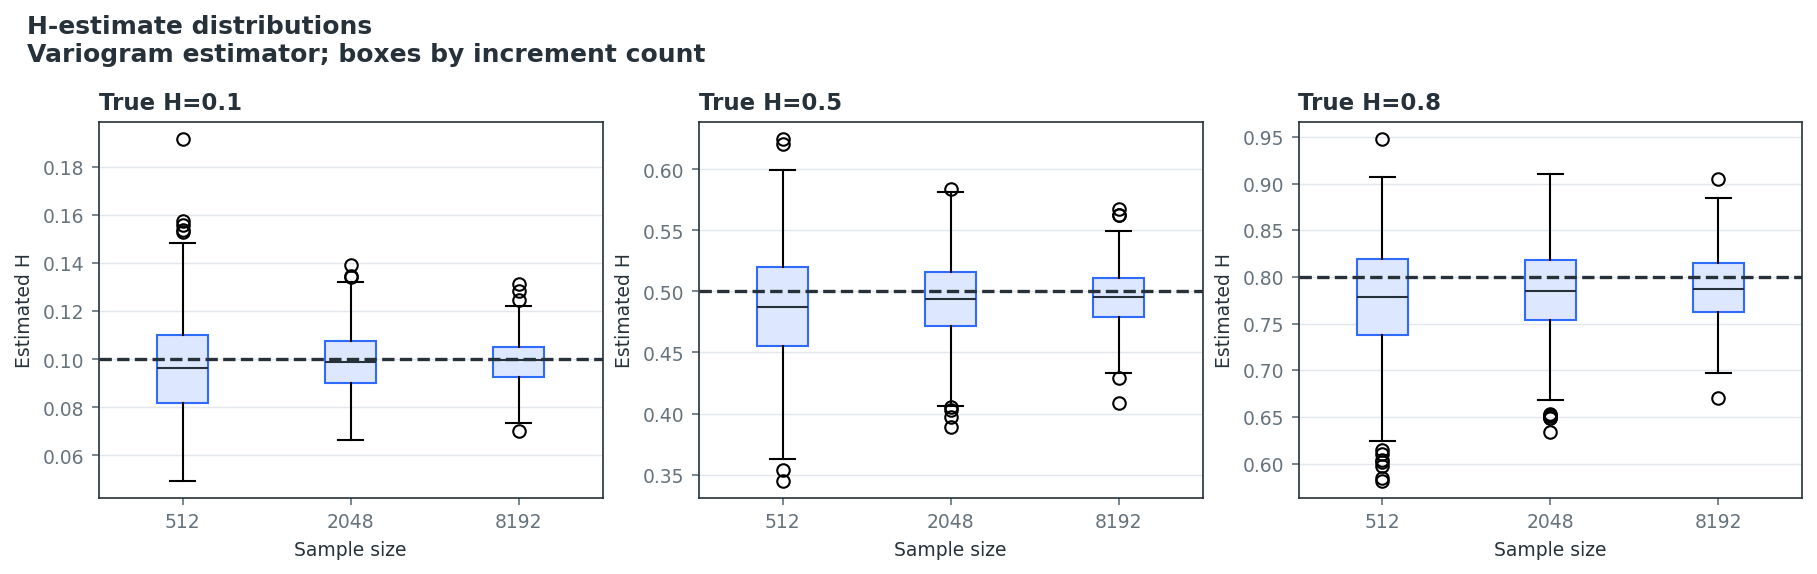

In [10]:
for figure_name in ['hurst_distributions']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="estimator-bias"></a>

## 11. Longer samples reduce, but do not erase, estimator bias

Bias and RMSE depend on the estimator, true $H$, and sample length. This is the clean-data baseline for the later noise study.

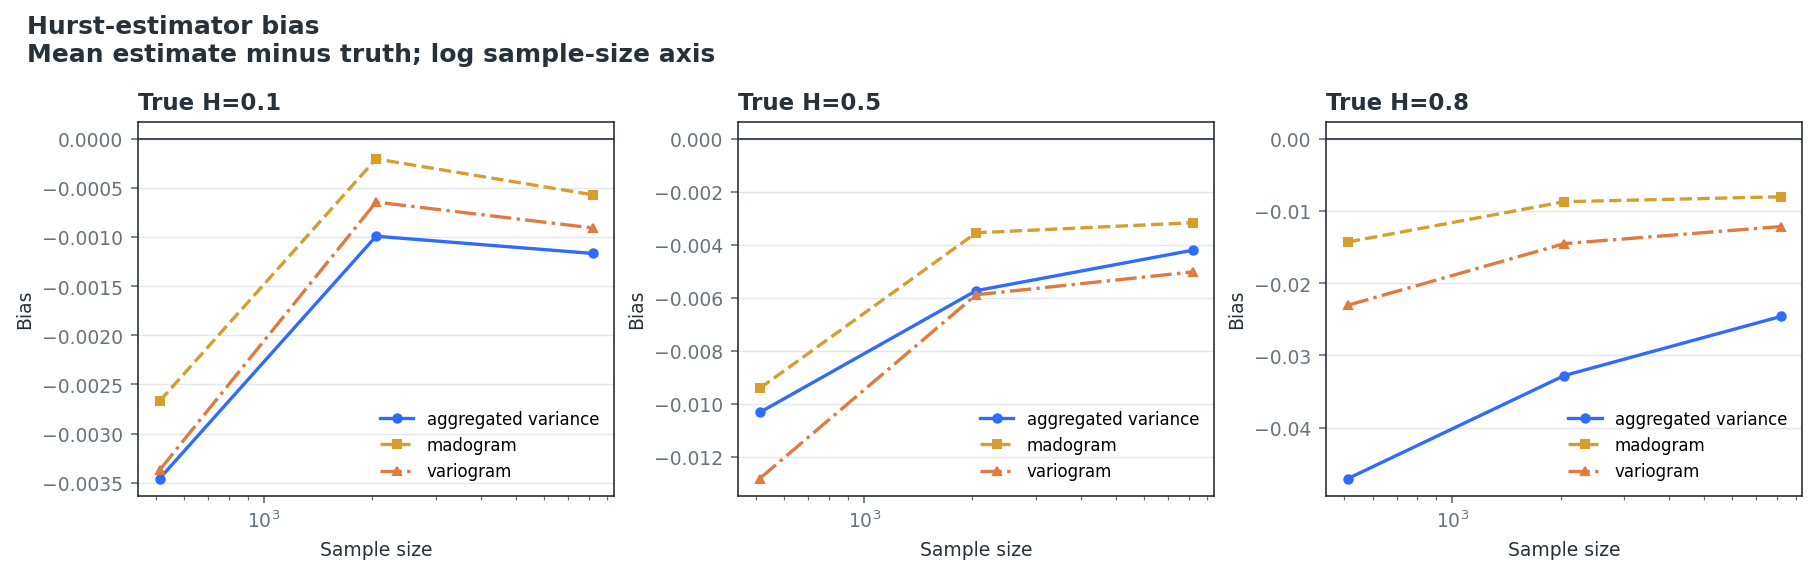

In [11]:
for figure_name in ['hurst_bias']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="ou-versus-fou"></a>

## 12. Rough log-volatility differs locally from ordinary OU

Ordinary and fractional OU log-volatility are matched in broad scale but differ sharply in local regularity. The fOU Euler path is visualization-grade, not an exact stationary sampler.

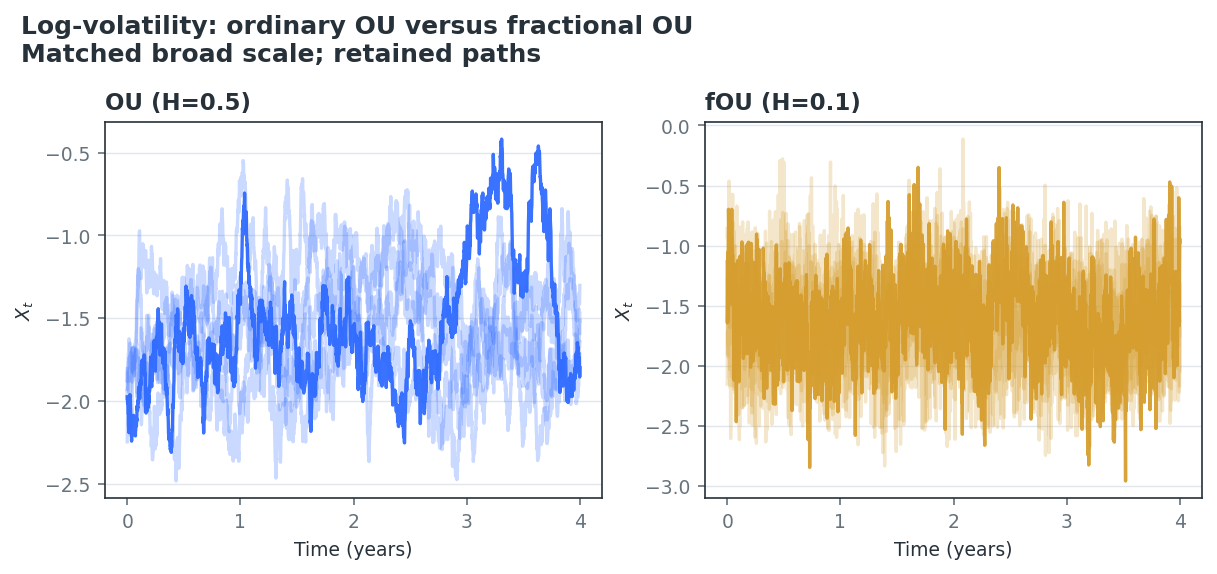

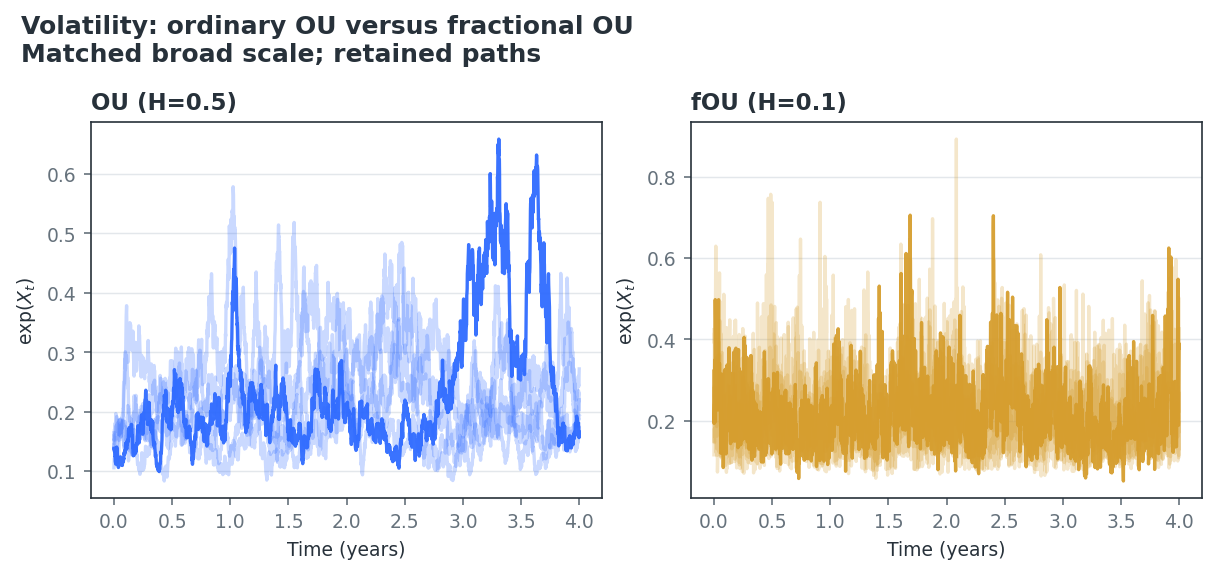

In [12]:
for figure_name in ['ou_vs_fou', 'ou_volatility']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="rough-bergomi-paths"></a>

## 13. Rough Bergomi creates abrupt variance dynamics

The exact-grid joint-Gaussian Volterra operator preserves $\mathbb E[V_t]=\xi_0(t)$ up to Monte Carlo error and produces abrupt variance paths.

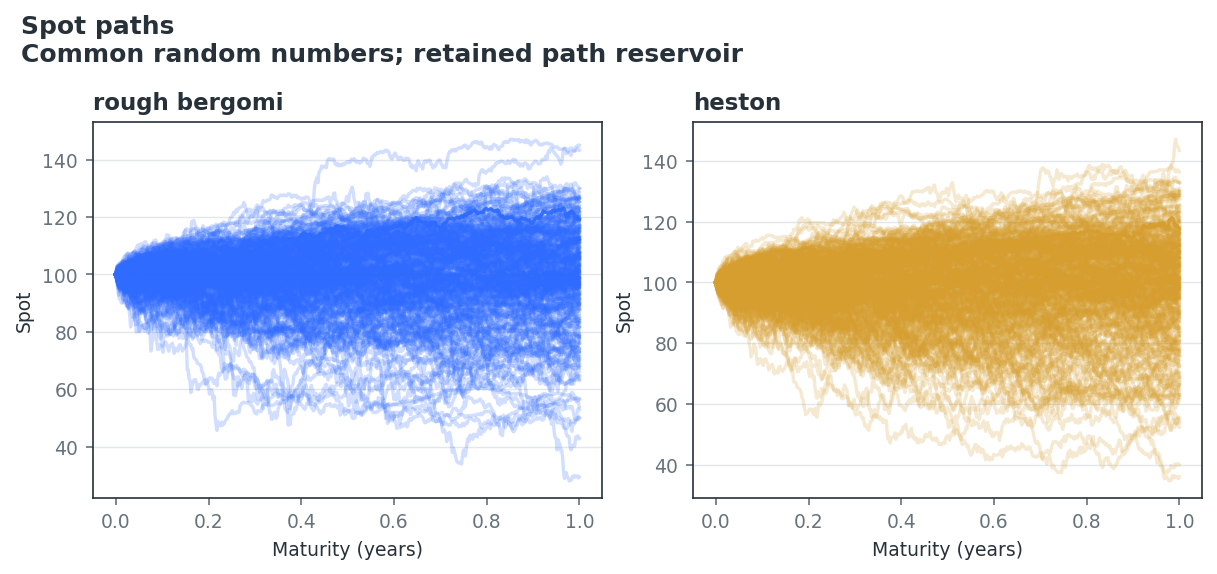

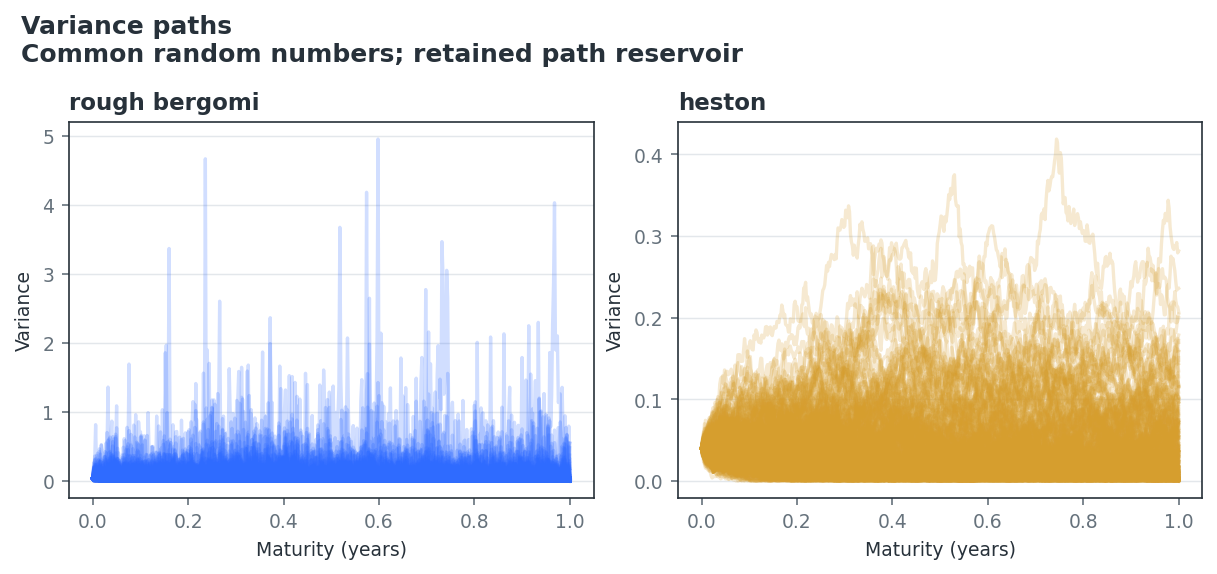

In [13]:
for figure_name in ['model_spot', 'model_variance']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="heston-comparison"></a>

## 14. The Markovian benchmark responds differently to shared shocks

Both models reuse the same standardized spot-driver normals. Remaining differences therefore reflect dynamics rather than a lucky shock draw; parameter matching is broad, not calibrated equivalence.

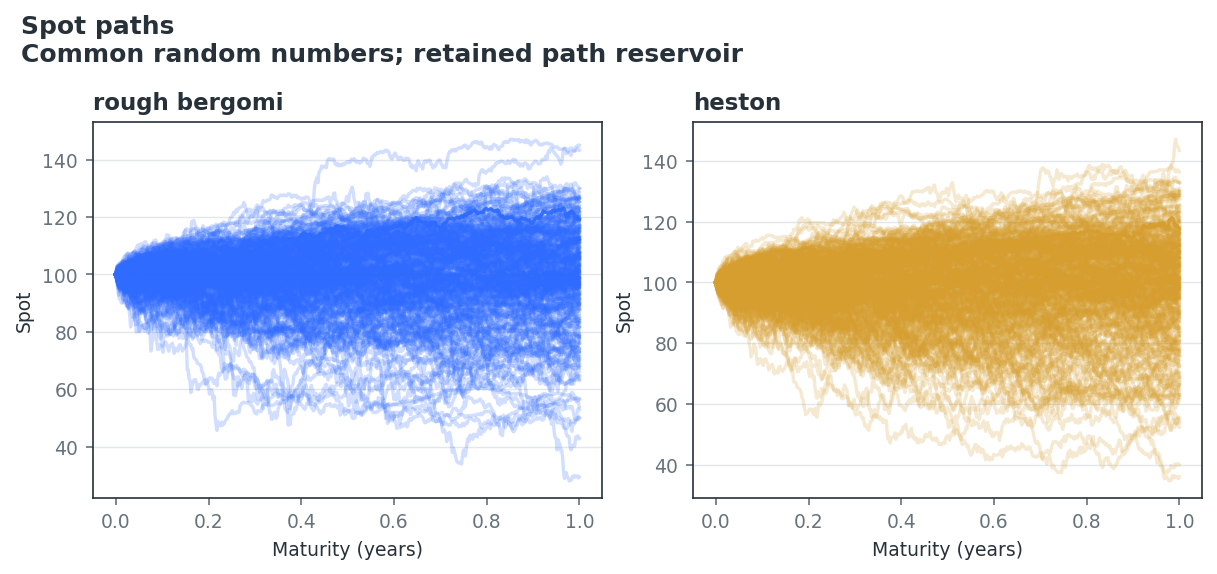

In [14]:
for figure_name in ['model_spot']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="terminal-distributions"></a>

## 15. Model dynamics change return and realized-variance distributions

Terminal returns and realized variance summarize consequences of the path dynamics on common density scales.

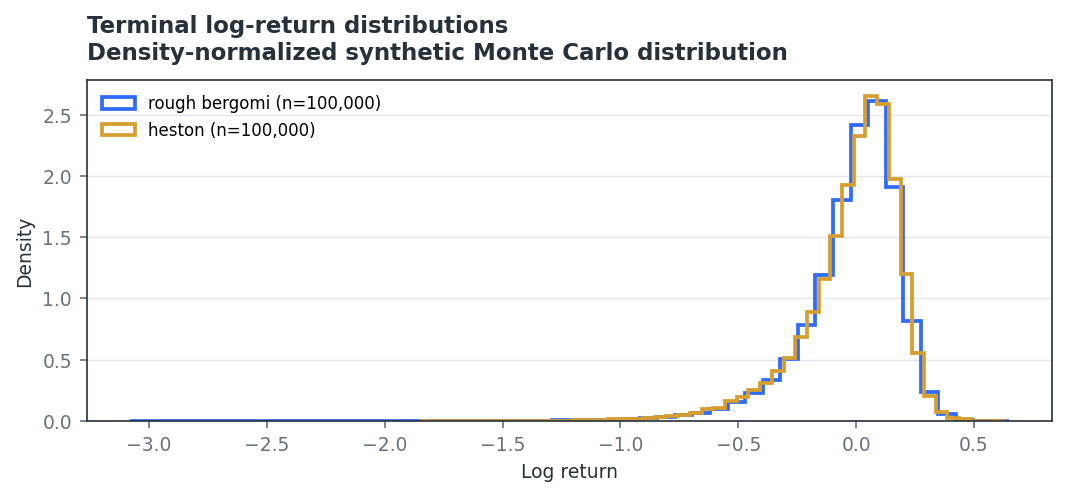

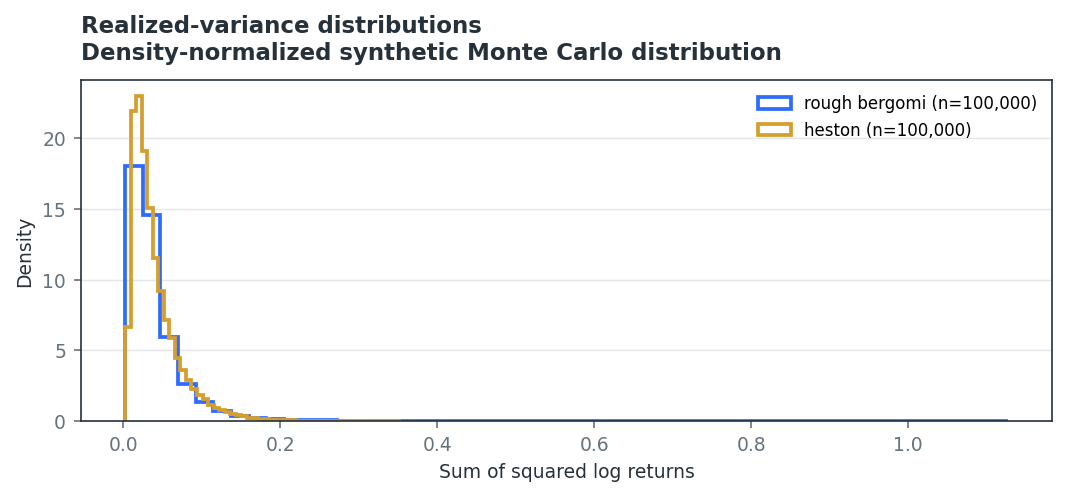

In [15]:
for figure_name in ['terminal_returns', 'realized_variance']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="iv-smiles"></a>

## 16. Smile shape varies jointly with model and maturity

Short-maturity wings have the largest Monte Carlo uncertainty. Error bars should be read before interpreting visual differences.

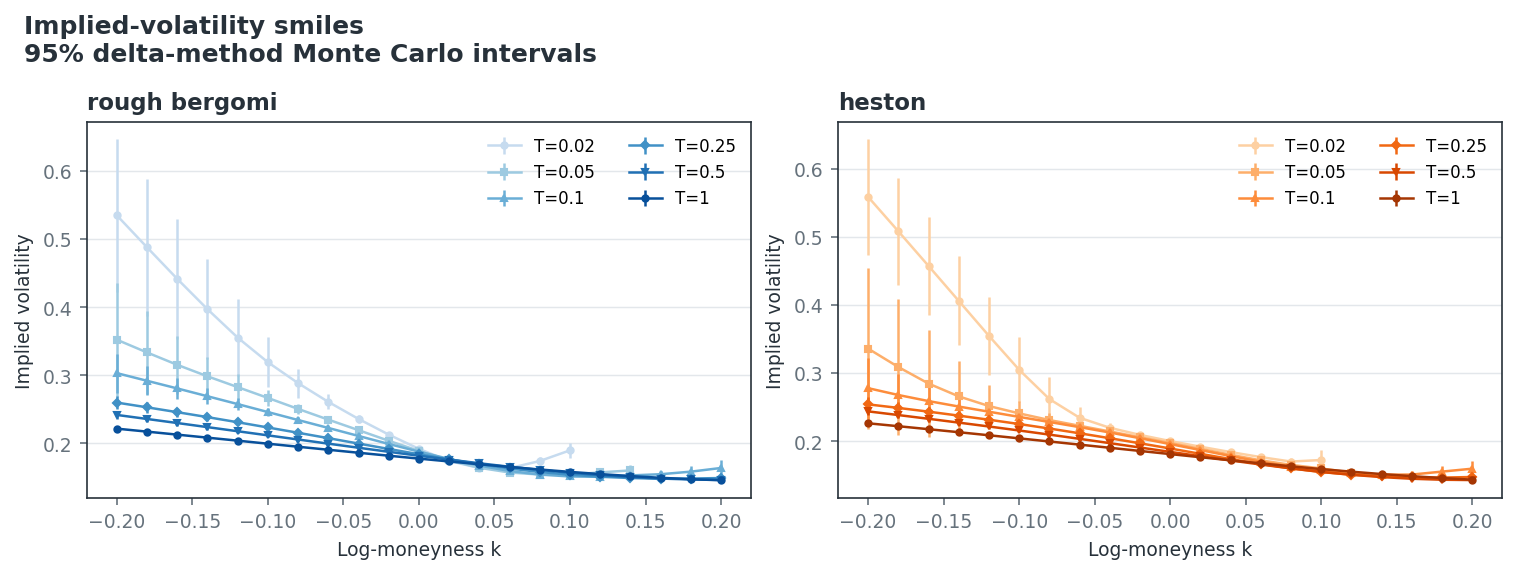

In [16]:
for figure_name in ['iv_smiles']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="iv-surface"></a>

## 17. The implied-volatility surface concentrates structure at short maturities

The heatmap view exposes where smile curvature and skew concentrate across log-moneyness and maturity.

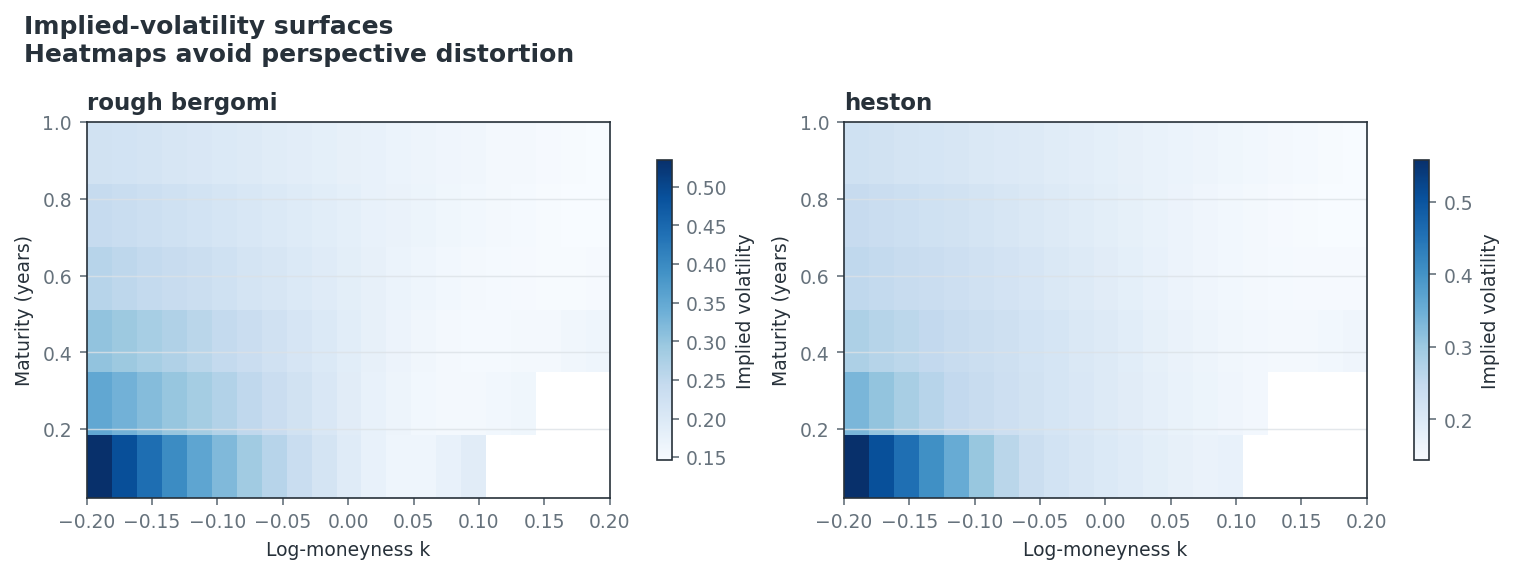

In [17]:
for figure_name in ['iv_surface']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="atm-skew-term"></a>

## 18. Smaller H produces stronger short-maturity ATM skew

Weighted local-quadratic fits estimate the ATM derivative and propagate IV uncertainty.

In [18]:
display(skew_power[['h', 'beta', 'beta_se', 'theoretical_beta', 'beta_error', 'r_squared']])

,h,beta,beta_se,theoretical_beta,beta_error,r_squared
0,0.05,-0.450419,0.004315,-0.45,-0.000419,0.999633
1,0.10,-0.405701,0.004015,-0.40,-0.005701,0.999608
2,0.20,-0.311825,0.001746,-0.30,-0.011825,0.999875
3,0.50,-0.013170,0.017137,0.00,-0.013170,0.128661


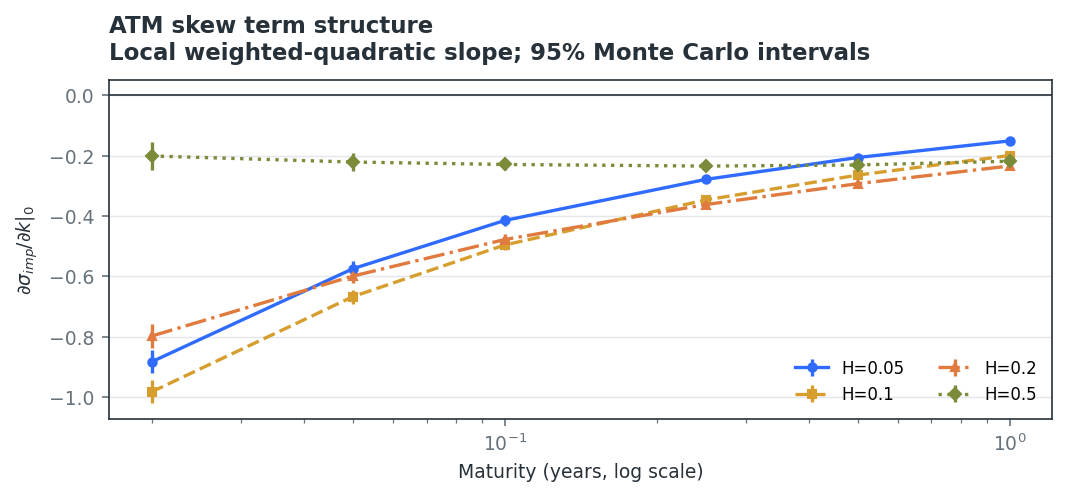

In [19]:
for figure_name in ['skew_term']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="skew-scaling"></a>

## 19. Finite-maturity skew follows the predicted power-law direction

The fitted finite-maturity exponent is compared with $H-1/2$ as a directional diagnostic, not an exact asymptotic proof.

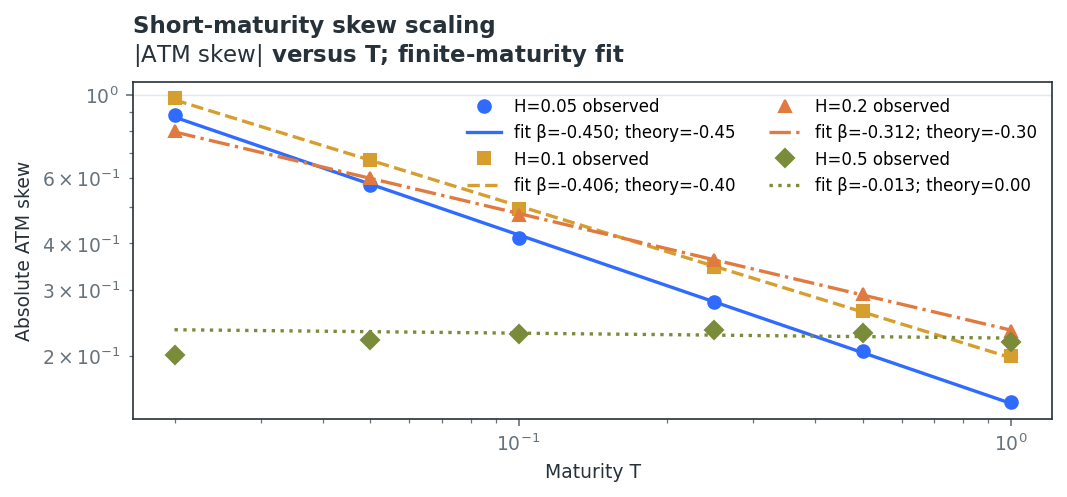

In [20]:
for figure_name in ['skew_scaling']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="hawkes-events"></a>

## 20. Near-critical Hawkes flow clusters into bursts

Rate-matched Poisson, stable, and near-critical Hawkes scenarios separate unconditional activity from self-exciting clustering.

In [21]:
display(hawkes_summary[['scenario', 'branching_ratio', 'event_count', 'expected_event_count', 'truncated']])

,scenario,branching_ratio,event_count,expected_event_count,truncated
0,poisson,0.00,39948,40000.0,False
1,stable,0.60,39627,40000.0,False
2,near_critical,0.97,38972,40000.0,False


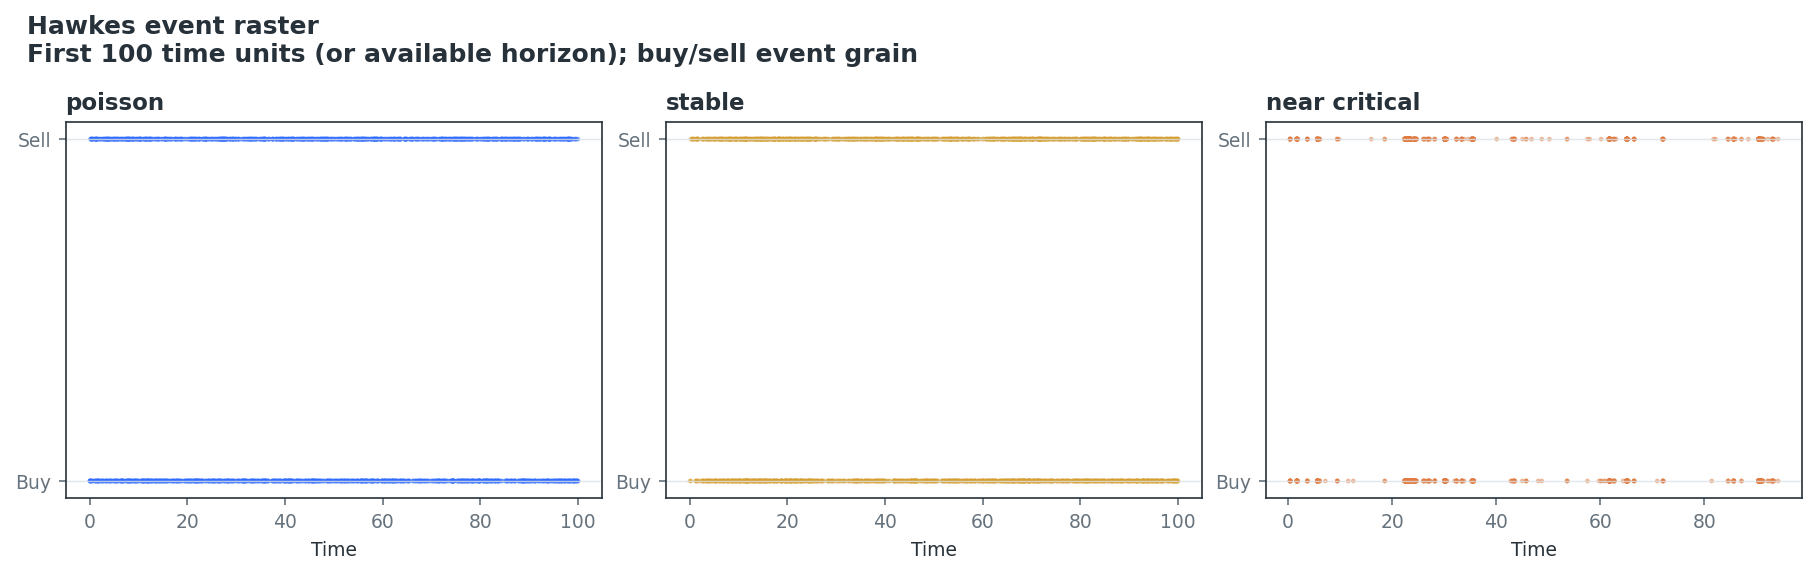

In [22]:
for figure_name in ['hawkes_events']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="order-flow-price"></a>

## 21. Signed event imbalance creates a clustered synthetic price

Signed order imbalance creates a simple synthetic price. It is deliberately pedagogical rather than a structural impact model.

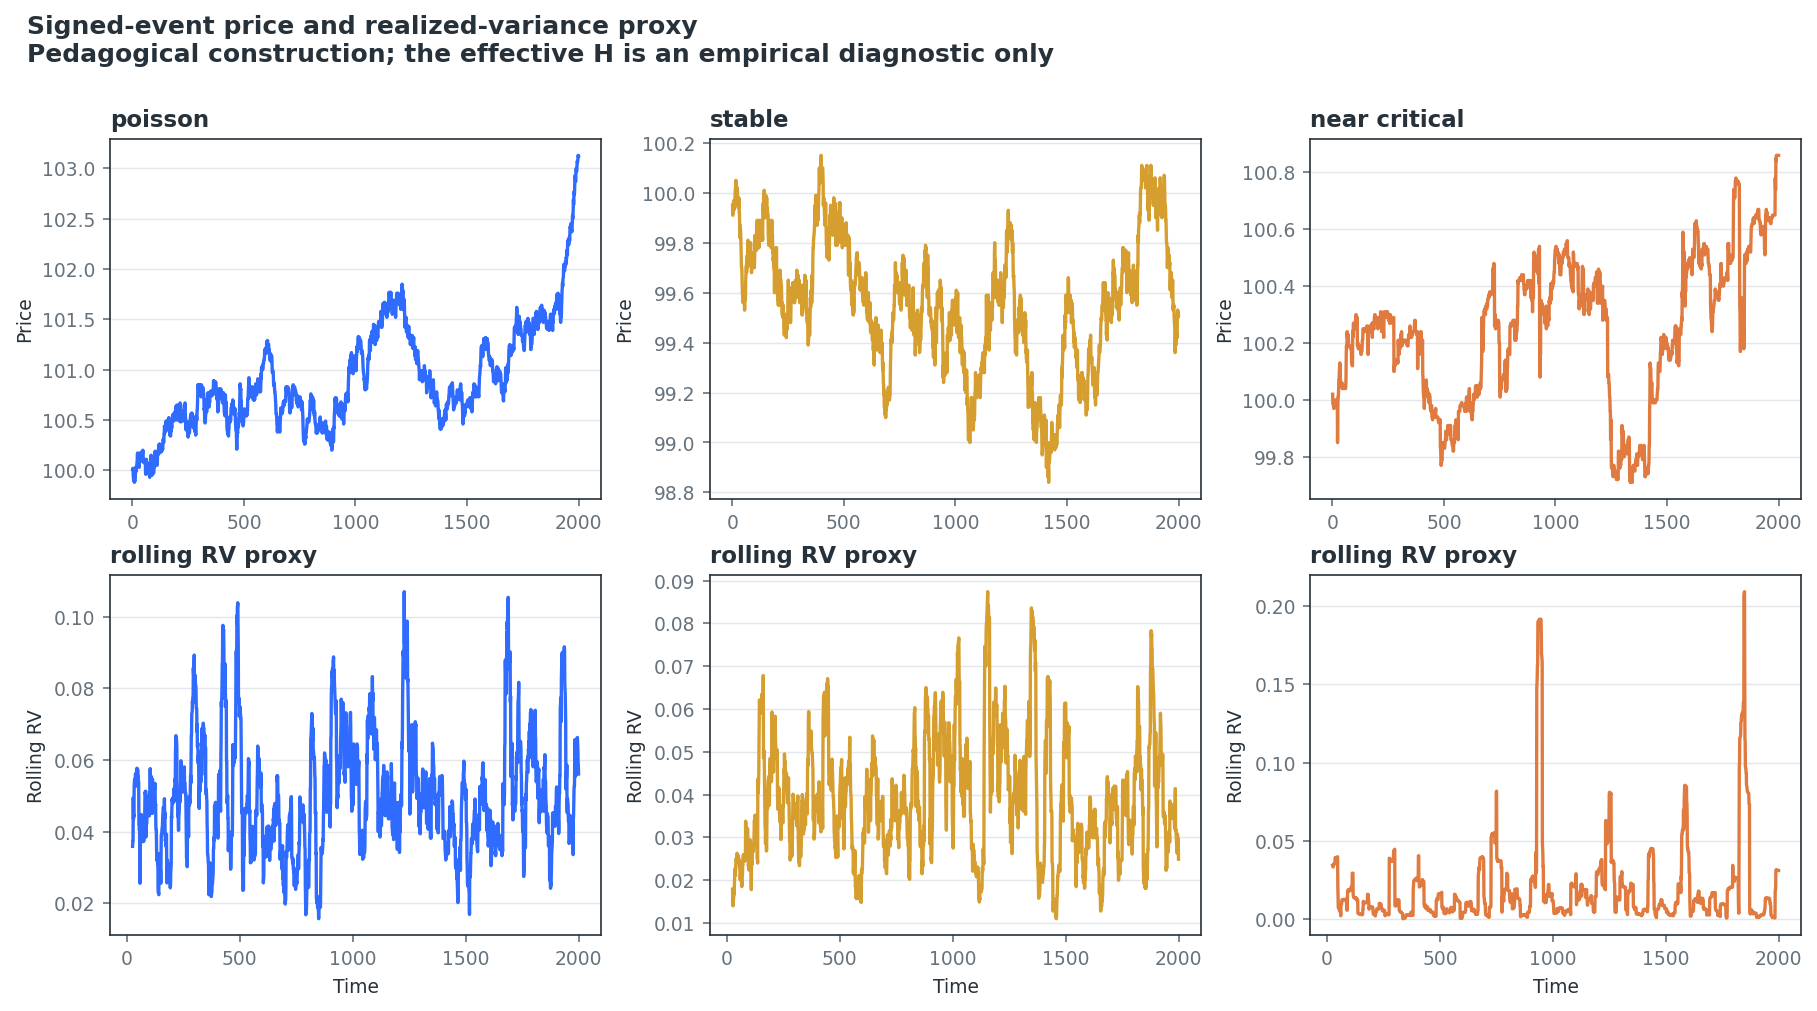

In [23]:
for figure_name in ['hawkes_price_rv']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="volatility-proxy"></a>

## 22. Clustered flow creates a rough-looking RV proxy

Intensity bursts and rolling squared returns form a rough-looking proxy. Its effective H is labeled as an empirical diagnostic only.

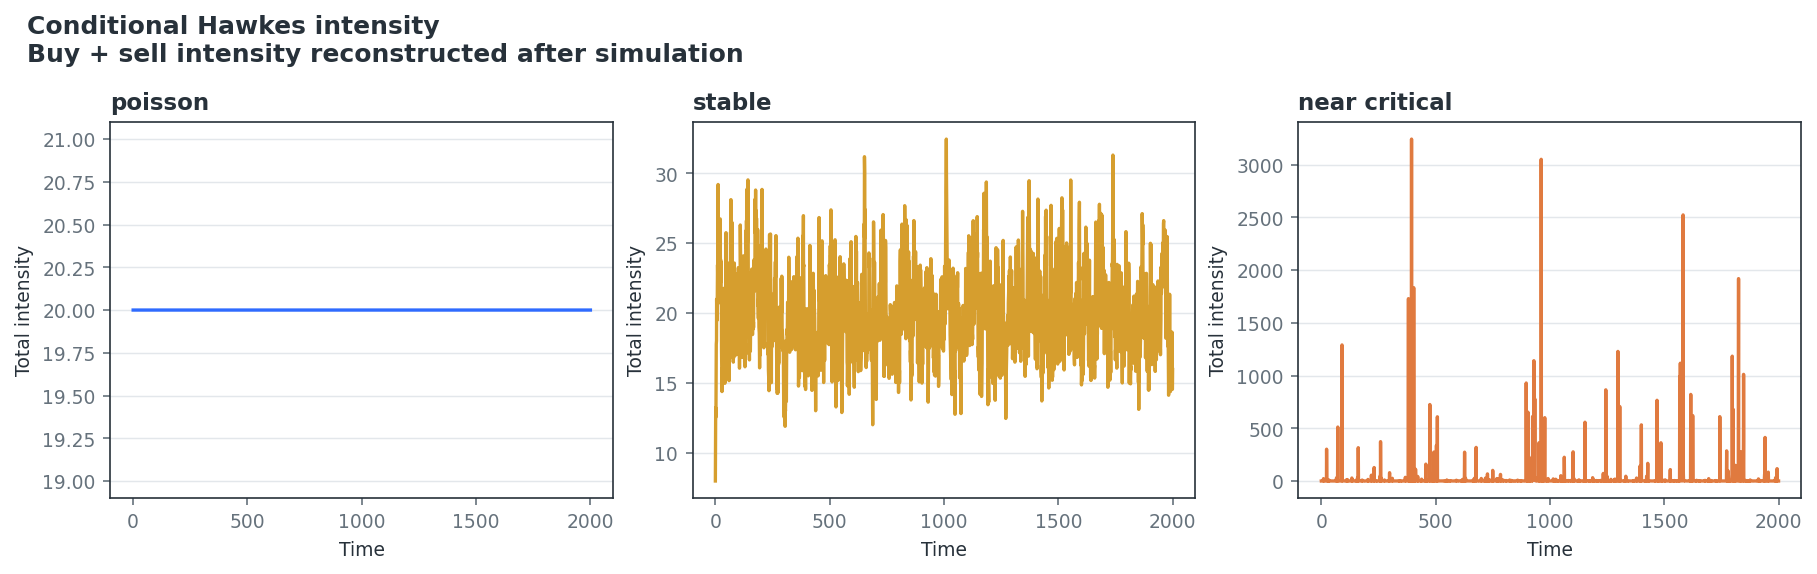

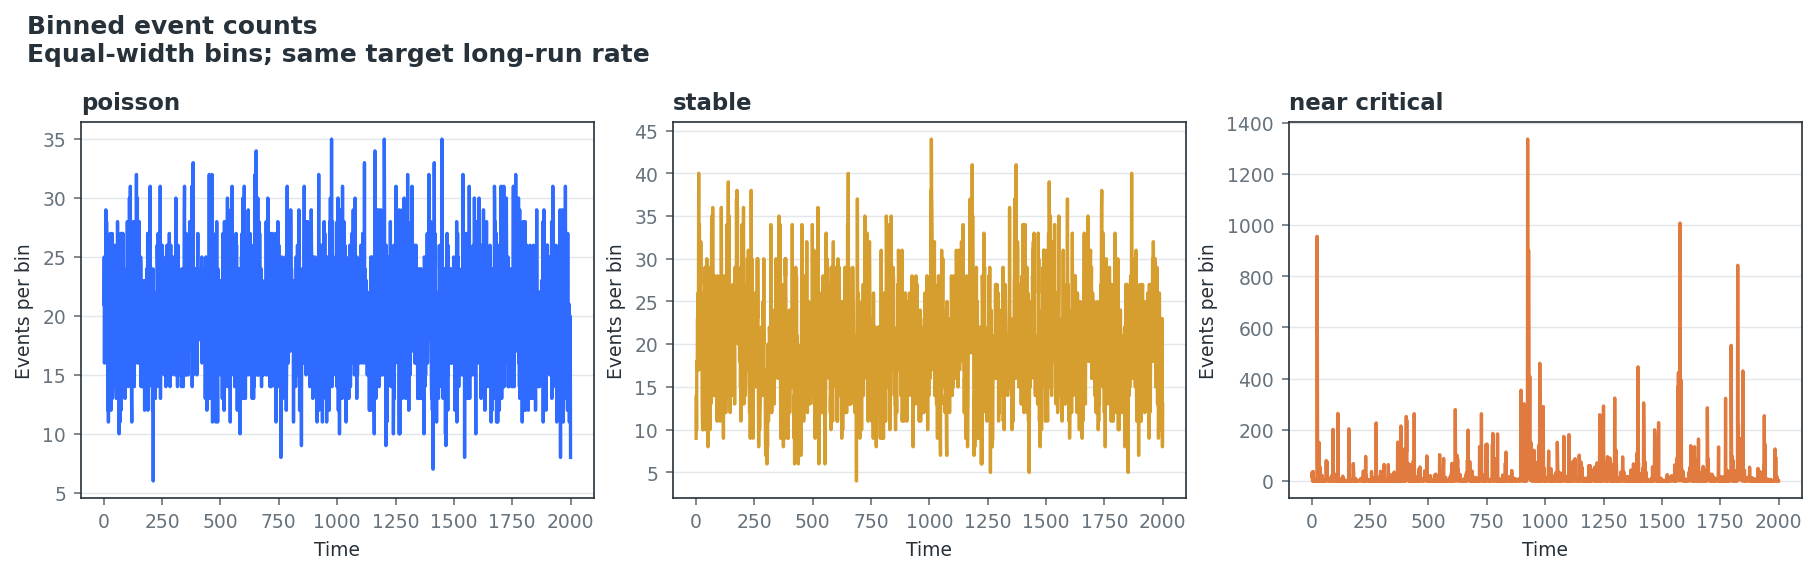

In [24]:
for figure_name in ['hawkes_intensity', 'hawkes_counts']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="noise-bias"></a>

## 23. Noise and sampling choices materially shift estimated H

The same latent paths yield different H estimates after changing observation noise, sampling stride, and preprocessing.

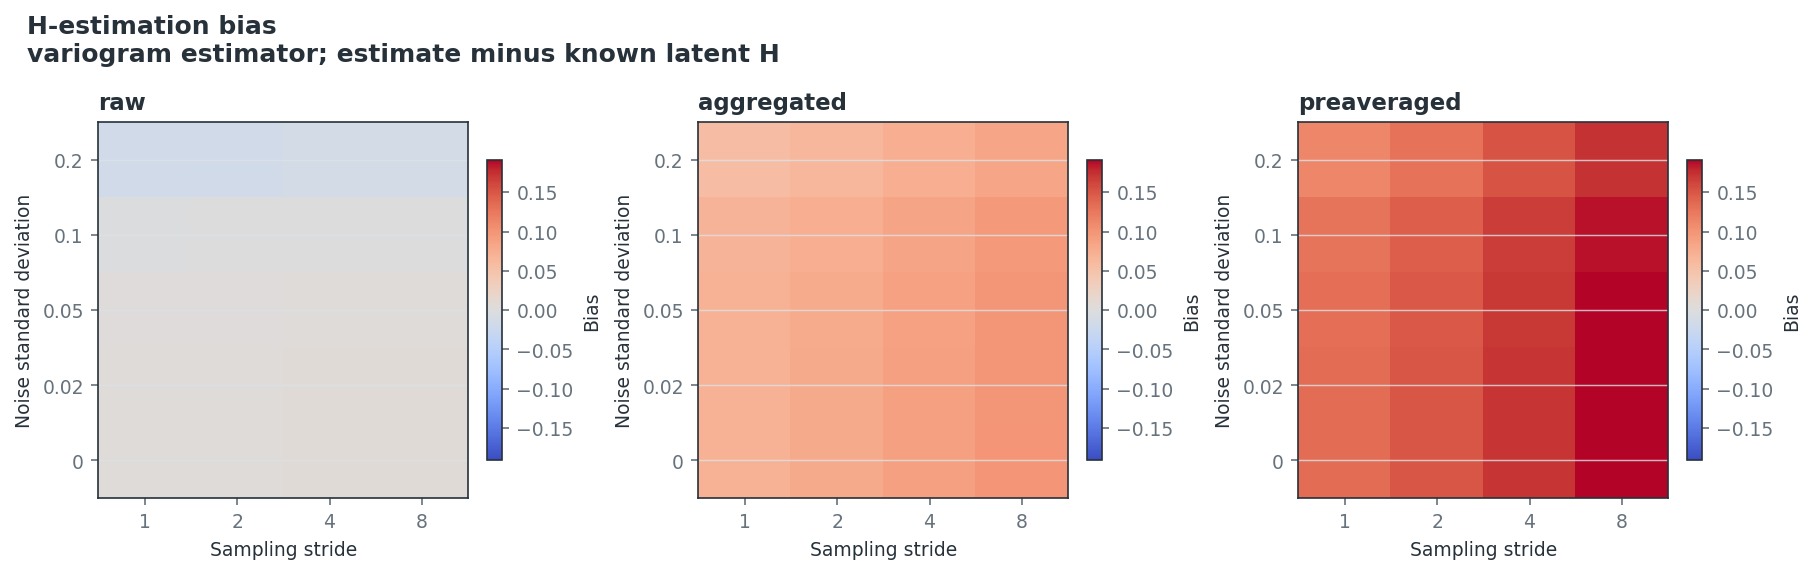

In [25]:
for figure_name in ['noise_bias']:
    path = figure_dir / f"{figure_name}.png"
    display(Image(filename=str(path)))


<a id="establishes"></a>

## 24. What the experiments establish

The experiments establish numerical scaling on clean simulations, forward-variance normalization, common-random-number model comparisons, finite-maturity skew direction, and the sufficiency of self-excitation for clustered proxies.

In [26]:
display(pd.DataFrame(validation['checks']).T)

,passed,fit,reported_not_tightly_asserted,diag_error,jitter_used
all_passed,True,True,True,True,True
hawkes_not_truncated,True,NaN,NaN,NaN,NaN
heston_variance_and_spot_moments,True,NaN,NaN,NaN,NaN
rough_skew_power_law,True,"{'beta': -0.405700736402866, 'beta_error': -0....",beta - (H - 1/2),NaN,NaN
rough_variance_and_spot_moments,True,NaN,NaN,NaN,NaN
volterra_diagonal,True,NaN,NaN,0.0,0.0


<a id="does-not-establish"></a>

## 25. What the experiments do not establish

They do not identify a fractional real-world data-generating process, calibrate either volatility model, derive rough Heston from Hawkes flow, or prove asymptotic skew exactly.

<a id="limitations-next-steps"></a>

## 26. Limitations, robustness, and next research steps

Next steps should emphasize robustness: calibrated forward variance, hybrid/FFT convergence checks, variance reduction for short-wing IV, noise-robust H estimators, and seasonality-aware Hawkes estimation. Further questions include sensitivity to leverage, vol-of-vol, grid design, and asynchronous sampling.